# 04 — Model Training, Evaluation & Explainability

Trains the baseline and four candidate models, cross-validates, tunes the top two,
selects a final model, and explains it with SHAP.

This notebook calls the exact same `src/train.py` pipeline used to produce the
model shipped with the Streamlit app — so the numbers below match `reports/model_results.csv`
and there is a single source of truth for the training logic.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
from src import train

results_df, final_model_name = train.main()

Train: (1176, 35), Test: (294, 35)
Train attrition rate: 0.162, Test: 0.160
Logistic Regression: CV F1=0.4818 (+/-0.0311), trained in 0.2s


Decision Tree: CV F1=0.3316 (+/-0.0814), trained in 0.2s


Random Forest: CV F1=0.3044 (+/-0.0832), trained in 1.1s


XGBoost: CV F1=0.4860 (+/-0.0506), trained in 0.6s

Cross-validation summary (5-fold stratified, scoring=F1):
  Logistic Regression: mean=0.4818, std=0.0311
  Decision Tree: mean=0.3316, std=0.0814
  Random Forest: mean=0.3044, std=0.0832
  XGBoost: mean=0.486, std=0.0506

Tuning top 2 models by CV F1: ['XGBoost', 'Logistic Regression']


XGBoost tuned -> best CV F1=0.5347, params={'clf__subsample': 0.7, 'clf__n_estimators': 150, 'clf__max_depth': 4, 'clf__learning_rate': 0.05}


Logistic Regression tuned -> best CV F1=0.5062, params={'clf__penalty': 'l2', 'clf__C': 0.01}

Final model selected: XGBoost (Tuned) -- highest F1 (attrition class) on held-out test set among tuned candidates.
Saved final model pipeline to /home/claude/employee-attrition-prediction/models/final_model.pkl
Saved model comparison table to /home/claude/employee-attrition-prediction/reports/model_results.csv

                      Model  Accuracy  Precision  Recall     F1  ROC-AUC
  Baseline (Majority Class)    0.8401     0.0000  0.0000 0.0000   0.5000
        Logistic Regression    0.7721     0.3780  0.6596 0.4806   0.8052
              Decision Tree    0.7857     0.3333  0.3404 0.3368   0.6054
              Random Forest    0.8469     0.6250  0.1064 0.1818   0.7893
                    XGBoost    0.8537     0.5769  0.3191 0.4110   0.7910
            XGBoost (Tuned)    0.8367     0.4894  0.4894 0.4894   0.7637
Logistic Regression (Tuned)    0.7415     0.3505  0.7234 0.4722   0.7943


## Model comparison table

In [2]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline (Majority Class),0.8401,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.7721,0.3780,0.6596,0.4806,0.8052
2,Decision Tree,0.7857,0.3333,0.3404,0.3368,0.6054
3,Random Forest,0.8469,0.6250,0.1064,0.1818,0.7893
4,XGBoost,0.8537,0.5769,0.3191,0.4110,0.7910
5,XGBoost (Tuned),0.8367,0.4894,0.4894,0.4894,0.7637
6,Logistic Regression (Tuned),0.7415,0.3505,0.7234,0.4722,0.7943


**Why not select on accuracy alone?** The dataset is imbalanced (~16% attrition).
A model that predicts "No" for everyone scores ~84% accuracy while catching zero
actual leavers (see the Baseline row: Recall = 0, F1 = 0). For an HR risk tool, the
cost of missing a leaver (a false negative) is high, so the final model is selected
on **F1-score for the Attrition class** on the held-out test set — the harmonic mean
of precision and recall — not accuracy.

## Confusion matrix, ROC curve, classification report

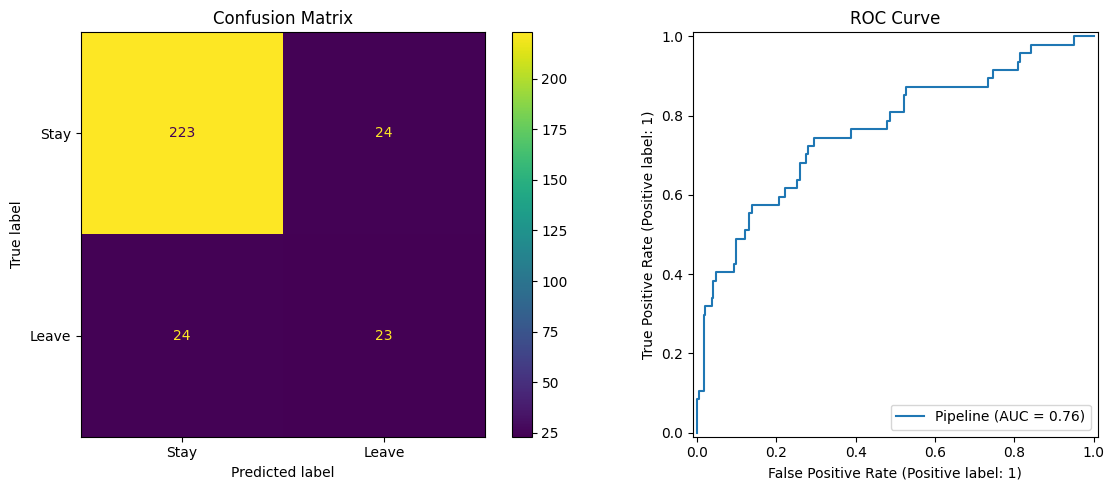

              precision    recall  f1-score   support

        Stay       0.90      0.90      0.90       247
       Leave       0.49      0.49      0.49        47

    accuracy                           0.84       294
   macro avg       0.70      0.70      0.70       294
weighted avg       0.84      0.84      0.84       294



In [3]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from src import config

bundle = joblib.load(config.MODEL_PATH)
artifacts = joblib.load(config.REPORTS_DIR / 'eval_artifacts.pkl')
pipeline = bundle['pipeline']
X_test, y_test = artifacts['X_test'], artifacts['y_test']
y_pred = pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], display_labels=['Stay', 'Leave'])
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

**Business impact of each error type:**
- **False Positive** — predicted to leave but actually stays: a wasted (but low-cost)
  retention conversation.
- **False Negative** — predicted to stay but actually leaves: **the costly error**.
  HR takes no preventive action, loses the employee with no warning, and incurs full
  replacement/hiring/training cost. Minimizing false negatives (maximizing recall on
  the Attrition class) is the priority for this use case.

## Explainability (SHAP)

In [4]:
from src import explain

feature_cols = bundle['feature_columns']
X_background = pd.concat([X_test]).reset_index(drop=True)
explainer, feature_names, mode = explain.build_explainer(pipeline, X_background)
print('Explainability mode:', mode)

importance_df = explain.global_feature_importance(pipeline, explainer, feature_names, X_test, mode)
importance_df['feature'] = importance_df['feature'].apply(explain.humanize_feature_name)
importance_df.head(15)

Explainability mode: shap


,feature,importance
0,OverTime No,0.575657
1,StockOptionLevel,0.345083
2,AvgSatisfactionScore,0.313658
3,Age,0.303662
4,MonthlyIncome,0.300586
5,DistanceFromHome,0.244165
6,JobStabilityScore,0.236131
7,DailyRate,0.214949
8,YearsWithCurrManager,0.199352
9,NumCompaniesWorked,0.181971


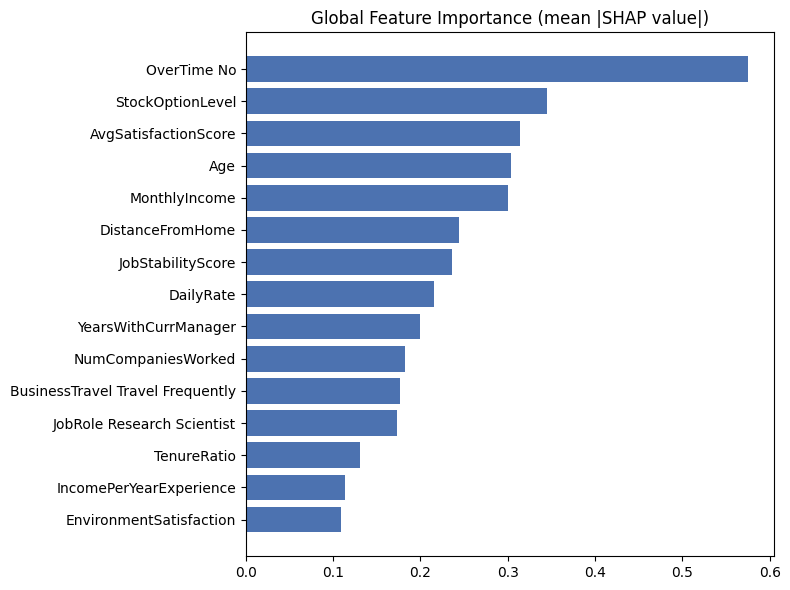

In [5]:
plt.figure(figsize=(8, 6))
top15 = importance_df.head(15).sort_values('importance')
plt.barh(top15['feature'], top15['importance'], color='#4C72B0')
plt.title('Global Feature Importance (mean |SHAP value|)' if mode == 'shap' else 'Global Feature Importance')
plt.tight_layout()
plt.show()

### Example: explaining one individual prediction

In [6]:
example_row = X_test.iloc[[0]]
proba = pipeline.predict_proba(example_row)[0, 1]
risk = config.probability_to_risk(proba)
factors = explain.explain_single_prediction(pipeline, explainer, feature_names, example_row, mode, top_n=4)
categorical_features = bundle['categorical_features']
for f in factors:
    f['feature'] = explain.humanize_feature_name(f['feature'], example_row, categorical_features)

print(f'Attrition Probability: {proba*100:.1f}%')
print(f'Risk Level: {risk}')
print('Top Contributing Factors:')
for i, f in enumerate(factors, 1):
    print(f"  {i}. {f['feature']} -> {f['effect']}")

Attrition Probability: 67.4%
Risk Level: MEDIUM
Top Contributing Factors:
  1. MonthlyIncome -> increases risk
  2. BusinessTravel: Non-Travel -> decreases risk
  3. YearsWithCurrManager -> increases risk
  4. OverTime: No -> decreases risk


**Note:** every value above (probabilities, factors, directions) is computed live
from the fitted model on this specific row — nothing is hard-coded. Re-running this
cell on a different row will produce a different explanation.